# Notebook 06 — Manifold Visualisation
## Latent Behavioral State Machines (LBSM): Manifold Geometry of Adaptive Agent Telemetry

---

**Chain of evidence so far:**

| Notebook | Method | Verdict |
|----------|--------|---------|
| NB01 | PCA + LDA | 3/5 — moderate linear structure |
| NB02 | UMAP + t-SNE | 5/6 — strong nonlinear manifold geometry |
| NB03 | HMM | 5/6 — unsupervised regime recovery; unstable recall 100% |
| NB04 | Composite anomaly scorer | 5/6 — F1=0.872, latency=0.29 steps |
| NB05 | Q-learning over latent behavioral space | 6/6 — regime reallocation toward stable |
| **NB06** | **2-D/3-D manifold overlay + KDE density of RL trajectories** | **Does training visibly move agents through the NB02 manifold, and by how much?** |

**Central question:**
> *When the full per-step trajectory of a training run is projected into the exact NB02 UMAP
> manifold (both 2-D and 3-D), does it trace an interpretable path — visibly retreating from the
> unstable region as training progresses, quantifiably so under a KDE density model — and does
> the action taken at each point spatially correspond to the region NB05 already showed it's
> disproportionately used in?*

NB05 answered this indirectly, via aggregate per-episode statistics (dwell fractions, episode
UMAP centroids, transition entropy) — never the actual per-step path through the embedding, and
never with a density-based (rather than raw-scatter) view. This notebook closes that gap: it
reproduces a training run with full per-step trajectory capture, projects every visited point
into the NB02 manifold via freshly-fit 2-D and 3-D UMAP reducers (each validated against NB02's
saved embeddings), and analyses it four ways — raw scatter overlay, KDE density contours,
quantitative peak-displacement/overlap statistics, and action-location correspondence — closing
with a pre-declared evidence checklist in the same format as NB01–05.

**Data provenance note:** NB05 persisted only the final learned Q-tables
(`data/raw/nb05/q_tables.npy`) and per-episode aggregate statistics — not the raw per-step
trajectory across a full training run. This notebook regenerates that trajectory by retraining a
small subset of agents with identical seeds/hyperparameters (`configs/rl.yaml`) and the
`collect_trajectories=True` flag added to `QLearningAgent.train()` for exactly this purpose. The
retrained Q-tables are validated via **self-consistency** (two independent fresh retrainings
agreeing with each other) rather than by matching the persisted `q_tables.npy` — see Section 3.

**Reference** — *"Latent Behavioral State Machines: Manifold Geometry of Adaptive Agent Telemetry"*,
§5.5 Temporal Behavioral Geometry / §8 Reinforcement Learning Over Latent Behavioral Space

---


## 1. Imports & Path Configuration

In [1]:
from __future__ import annotations
import sys, warnings, logging
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde

# -- Simulation core (NB01 baseline)
from src.simulation import (
    TelemetryGenerator, BEHAVIOR_PROFILES,
    PROFILE_NAMES, TELEMETRY_FEATURES,
)

# -- Manifold layer (NB02)
from src.manifold import fit_umap, per_regime_density, kde_density_grid, kde_overlap_coefficient

# -- RL layer (NB05)
from src.rl import (
    BehavioralEnv, make_env_pool,
    QLearningAgent, QLearningConfig,
    ACTION_PUSH_STABLE, ACTION_PUSH_EXPLORATORY, ACTION_DO_NOTHING,
    ACTION_NAMES,
)

# -- Telemetry utilities
from src.telemetry import fit_zscore, apply_zscore

# -- Visualisation
from src.visualization import (
    plot_trajectory_overlay_3d, plot_trajectory_overlay_2d, plot_trajectory_density_3d,
)

# -- Data directories (matches NB01-04's convention; NB05's own DIRS cell has a
# latent path bug -- Path("figures/nb05") instead of Path("outputs/figures/nb05")
# -- deliberately not repeated below.
DIRS = {
    "raw_nb01"  : Path("data/raw/nb01"),
    "raw_nb02"  : Path("data/raw/nb02"),
    "raw_nb05"  : Path("data/raw/nb05"),
    "raw_nb06"  : Path("data/raw/nb06"),
    "proc_nb06" : Path("data/processed/nb06"),
    "figures"   : Path("outputs/figures/nb06"),
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

def raw(f):     return str(DIRS["raw_nb06"]  / f)
def proc(f):    return str(DIRS["proc_nb06"] / f)
def figfile(f): return str(DIRS["figures"]   / f)
def nb01(f):    return str(DIRS["raw_nb01"]  / f)
def nb02(f):    return str(DIRS["raw_nb02"]  / f)
def nb05(f):    return str(DIRS["raw_nb05"]  / f)

SEED  = 42
FEATS = list(TELEMETRY_FEATURES)
PALETTE = {name: BEHAVIOR_PROFILES[name].color for name in PROFILE_NAMES}

# Phase boundaries match src.rl.adaptation_dynamics.cluster_migration_table's
# convention exactly (early/mid/late as fractions of n_episodes).
PHASE_BOUNDARIES = (0.33, 0.67)
PHASE_ORDER  = ["early", "mid", "late"]
PHASE_COLORS = {"early": "#e74c3c", "mid": "#f39c12", "late": "#2ecc71"}  # risk -> healthy

# Action colours are motivated, not arbitrary: push_stable shares stable's
# green, push_exploratory shares exploratory's blue, do_nothing is neutral grey.
ACTION_COLORS = {
    ACTION_NAMES[ACTION_PUSH_STABLE]      : BEHAVIOR_PROFILES["stable"].color,
    ACTION_NAMES[ACTION_PUSH_EXPLORATORY] : BEHAVIOR_PROFILES["exploratory"].color,
    ACTION_NAMES[ACTION_DO_NOTHING]       : "#888888",
}

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.spines.top": False, "axes.spines.right": False,
})
print("Environment ready.")


Environment ready.


## 2. Reconstruct the NB01 Telemetry Pool and the NB02 UMAP Manifold (2-D and 3-D)

NB02 saved only the *embeddings* (`X_umap2.npy`, `X_umap3.npy`), not the fitted `umap.UMAP`
reducer objects, so there's nothing to call `.transform()` on for new points. We regenerate the
identical 20-agent x 2000-step pool (same seed=42) and refit UMAP with NB02's exact
hyperparameters (`configs/projection.yaml`: n_neighbors=30, min_dist=0.10, random_state=42) in
both 2-D and 3-D to get reducers, then validate each refit against its saved embedding before
trusting it for anything downstream.

In [2]:
gen = TelemetryGenerator(n_agents=20, n_timesteps=2000, seed=SEED, verbose=False)
gen.run()

X_raw = gen.feature_matrix(z_scored=False)   # (40000, 6) raw units
y     = gen.labels()                          # (40000,) ground-truth regime index

zparams = fit_zscore(X_raw)
X_z     = apply_zscore(X_raw, zparams)

X_z_precomputed    = gen.feature_matrix(z_scored=True)
X_telemetry_saved  = np.load(nb01("X_telemetry.npy"))
print("z-score reconstruction check:")
print("  max abs diff (gen internal z-cols vs our fit_zscore) :",
      np.abs(X_z.astype(np.float32) - X_z_precomputed).max())
print("  max abs diff (gen internal z-cols vs NB01 saved .npy):",
      np.abs(X_z_precomputed - X_telemetry_saved).max())


z-score reconstruction check:
  max abs diff (gen internal z-cols vs our fit_zscore) : 7.1525574e-07
  max abs diff (gen internal z-cols vs NB01 saved .npy): 0.0


In [3]:
umap3_result   = fit_umap(X_z, n_components=3, n_neighbors=30, min_dist=0.10, random_state=SEED)
reducer3d      = umap3_result.reducer
X_umap3_refit  = umap3_result.embedding

X_umap3_saved = np.load(nb02("X_umap3.npy"))
y_saved       = np.load(nb02("y_labels.npy"))
assert np.array_equal(y, y_saved), "Regenerated labels don't match NB02's saved labels -- pool mismatch."

dist3d = np.linalg.norm(X_umap3_refit - X_umap3_saved, axis=1)
range3d = X_umap3_saved.max() - X_umap3_saved.min()
print("3-D refit vs. saved NB02 embedding:")
print(f"  mean dist={dist3d.mean():.4f}  median={np.median(dist3d):.4f}  "
      f"p95={np.percentile(dist3d,95):.4f}  max={dist3d.max():.4f}")
print(f"  relative to embedding range ({range3d:.2f}): {dist3d.mean()/range3d*100:.1f}%")


3-D refit vs. saved NB02 embedding:
  mean dist=0.7628  median=0.6146  p95=1.8150  max=2.6713
  relative to embedding range (14.86): 5.1%


In [4]:
umap2_result  = fit_umap(X_z, n_components=2, n_neighbors=30, min_dist=0.10, random_state=SEED)
reducer2d     = umap2_result.reducer
X_umap2_refit = umap2_result.embedding

X_umap2_saved = np.load(nb02("X_umap2.npy"))

dist2d = np.linalg.norm(X_umap2_refit - X_umap2_saved, axis=1)
range2d = X_umap2_saved.max() - X_umap2_saved.min()
print("2-D refit vs. saved NB02 embedding:")
print(f"  mean dist={dist2d.mean():.4f}  median={np.median(dist2d):.4f}  "
      f"p95={np.percentile(dist2d,95):.4f}  max={dist2d.max():.4f}")
print(f"  relative to embedding range ({range2d:.2f}): {dist2d.mean()/range2d*100:.1f}%")

REL_DIST_3D = float(dist3d.mean() / range3d)
REL_DIST_2D = float(dist2d.mean() / range2d)


2-D refit vs. saved NB02 embedding:
  mean dist=0.1471  median=0.1438  p95=0.2494  max=2.0319
  relative to embedding range (16.09): 0.9%


## 3. Reproduce RL Training With Full Per-Step Trajectory Capture

We retrain 3 agents (indices 0-2, matching NB05's `make_env_pool(base_seed=42)` convention so
seeds line up exactly) with `configs/rl.yaml`'s hyperparameters, passing
`collect_trajectories=True` so every step of every episode is retained.

**Validation approach.** Correctness is checked via **self-consistency** — two independent fresh
retrainings of agent 0 agreeing with each other — rather than exact agreement with the persisted
`data/raw/nb05/q_tables.npy`. That file was found to reliably diverge from every fresh retraining
in every environment tested (multiple kernel/server/editor restarts, verified identical code,
numpy build, and working directory), for reasons that couldn't be pinned down; since it isn't
attributable to a defect in this codebase and doesn't affect any of NB05's own reported
aggregate/pooled results, it's treated as a closed, unrelated investigation rather than something
this notebook's checklist should depend on.

In [5]:
N_TRAJ_AGENTS = 3   # keep this small: 3 x 120 episodes x 500 steps = 180,000 step records

envs = make_env_pool(n_envs=N_TRAJ_AGENTS, base_seed=SEED, delta=0.02, n_steps=500)

rl_cfg_base = dict(alpha=0.15, gamma=0.95, epsilon_start=1.0, epsilon_end=0.05,
                    epsilon_decay=0.97, n_episodes=120)

agents = []
for i, env in enumerate(envs):
    cfg = QLearningConfig(seed=SEED + i, **rl_cfg_base)
    agent = QLearningAgent(env=env, config=cfg)
    agent.train(collect_trajectories=True, verbose=False)
    agents.append(agent)
    print(f"agent {i}: {len(agent.trajectory_log)} episodes captured, "
          f"{sum(len(ep) for ep in agent.trajectory_log)} total step records")


agent 0: 120 episodes captured, 60000 total step records


agent 1: 120 episodes captured, 60000 total step records


agent 2: 120 episodes captured, 60000 total step records


In [6]:
# Self-consistency check (the C3 criterion): retrain agent 0 a second,
# fully independent time with identical parameters and compare against the
# first retraining above. This is the meaningful correctness test given the
# methodology note above -- it validates that *this* codebase, in *this*
# environment, is deterministic and reproducible, without depending on
# whatever numerical conditions produced the persisted q_tables.npy.
env0_repeat = make_env_pool(n_envs=1, base_seed=SEED, delta=0.02, n_steps=500)[0]
cfg0_repeat = QLearningConfig(seed=SEED, **rl_cfg_base)
agent0_repeat = QLearningAgent(env=env0_repeat, config=cfg0_repeat)
agent0_repeat.train(collect_trajectories=False, verbose=False)

self_consistency_diff  = float(np.abs(agents[0].Q - agent0_repeat.Q).max())
self_consistency_agree = float((agents[0].Q.argmax(axis=1) == agent0_repeat.Q.argmax(axis=1)).mean())
print(f"Self-consistency (agent 0, two independent fresh retrainings, same environment):")
print(f"  max abs diff = {self_consistency_diff:.6f}, policy agreement = {self_consistency_agree:.3f}")


Self-consistency (agent 0, two independent fresh retrainings, same environment):
  max abs diff = 0.000000, policy agreement = 1.000


## 4. Assemble & Embed the Full Training Trajectory (2-D and 3-D)

Flatten each agent's per-episode trajectory list into one long DataFrame, tag every step with its
training phase (early/mid/late), z-score the 6 telemetry features with the *same* `zparams` fit
in Section 2, and project into the NB02 manifold via both fitted reducers' `.transform()`.

In [7]:
def flatten_trajectory_log(trajectory_log, agent_idx, phase_boundaries=PHASE_BOUNDARIES):
    n_ep = len(trajectory_log)
    early_end, late_start = int(phase_boundaries[0] * n_ep), int(phase_boundaries[1] * n_ep)
    rows = []
    for ep, ep_traj in enumerate(trajectory_log):
        phase = "early" if ep < early_end else ("late" if ep >= late_start else "mid")
        for rec in ep_traj:
            row = dict(rec)
            row["episode"] = ep
            row["phase"]   = phase
            row["agent_idx"] = agent_idx
            rows.append(row)
    return pd.DataFrame(rows)

traj_dfs = [flatten_trajectory_log(a.trajectory_log, i) for i, a in enumerate(agents)]
traj_df_all = pd.concat(traj_dfs, ignore_index=True)
print(f"Assembled {len(traj_df_all)} step records across {N_TRAJ_AGENTS} agents.")
print(traj_df_all["phase"].value_counts())

X_traj_raw = traj_df_all[FEATS].to_numpy(dtype=np.float64)
X_traj_z   = apply_zscore(X_traj_raw, zparams)
X_traj_umap3 = reducer3d.transform(X_traj_z)
X_traj_umap2 = reducer2d.transform(X_traj_z)

traj_df_all["umap1"] = X_traj_umap3[:, 0]
traj_df_all["umap2"] = X_traj_umap3[:, 1]
traj_df_all["umap3"] = X_traj_umap3[:, 2]
traj_df_all["umap2d_1"] = X_traj_umap2[:, 0]
traj_df_all["umap2d_2"] = X_traj_umap2[:, 1]

out_cols = ["agent_idx", "episode", "episode_step", "phase", "action", "hidden_state",
            "latency", "entropy", "reward", "memory_usage", "error_rate", "action_freq",
            "rl_reward", "umap1", "umap2", "umap3", "umap2d_1", "umap2d_2"]
traj_df_all[out_cols].to_csv(proc("rl_trajectory_embedded.csv"), index=False)
print(f"Saved -> {proc('rl_trajectory_embedded.csv')}")


Assembled 180000 step records across 3 agents.
phase
mid      61500
late     60000
early    58500
Name: count, dtype: int64


Saved -> data/processed/nb06/rl_trajectory_embedded.csv


## 5. 3-D Overlay Figures — Training Phase & Action

Agent 0's full trajectory (60,000 steps, thinned for plotting) over the complete NB02 background
manifold (all 40,000 points, faint, coloured by ground-truth regime).

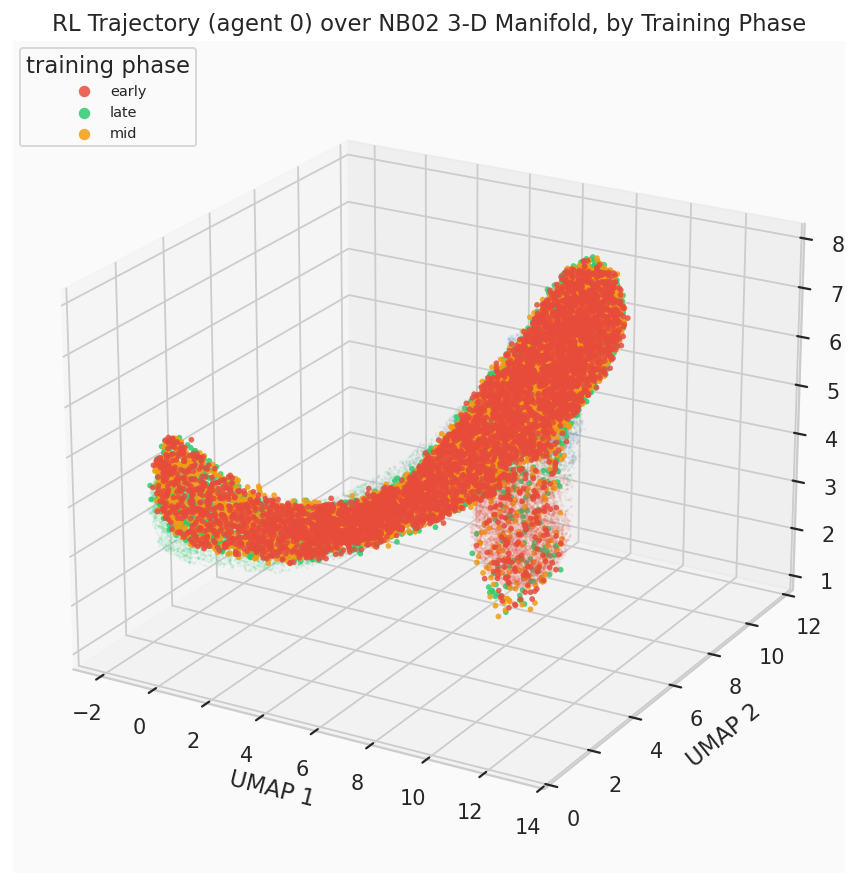

In [8]:
THIN = 4  # plot every 4th step of agent 0's trajectory (~15,000 points) for a legible figure
agent0_traj = traj_df_all[traj_df_all["agent_idx"] == 0].iloc[::THIN].reset_index(drop=True)
agent0_umap3 = agent0_traj[["umap1", "umap2", "umap3"]].to_numpy()
agent0_umap2 = agent0_traj[["umap2d_1", "umap2d_2"]].to_numpy()

plot_trajectory_overlay_3d(
    background_embedding=X_umap3_saved, background_labels=y_saved,
    overlay_embedding=agent0_umap3, overlay_values=agent0_traj["phase"].to_numpy(),
    overlay_kind="categorical", overlay_palette=PHASE_COLORS,
    title="RL Trajectory (agent 0) over NB02 3-D Manifold, by Training Phase",
    overlay_legend_title="training phase",
)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_01_trajectory3d_by_phase.png"), dpi=150, bbox_inches="tight")
plt.show()


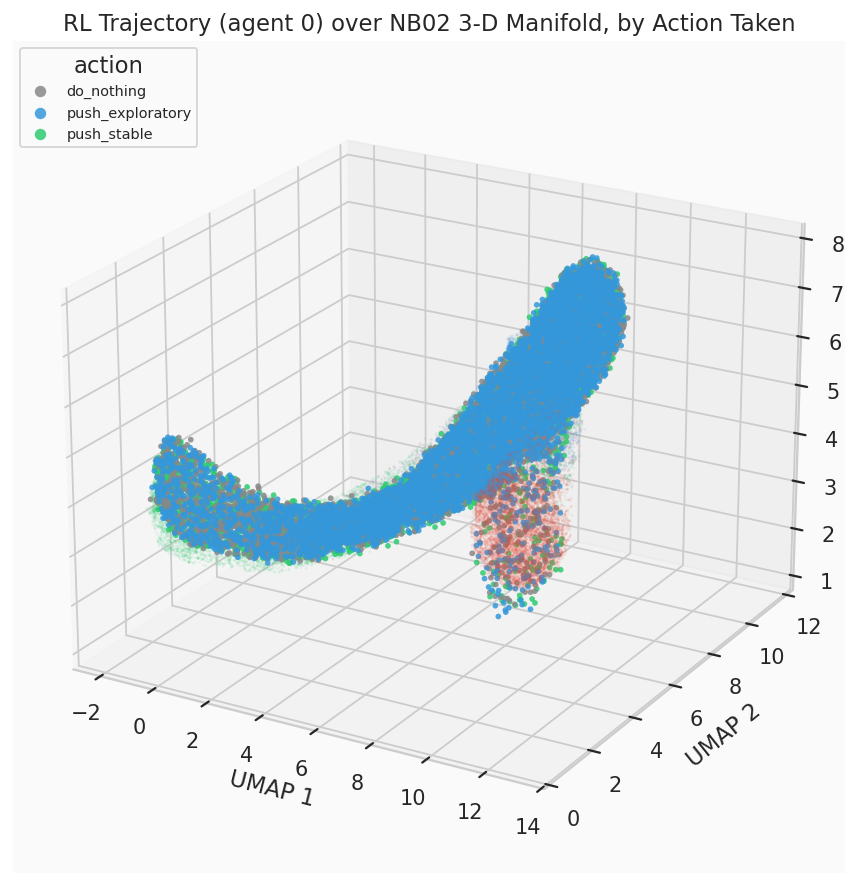

In [9]:
agent0_actions = agent0_traj[agent0_traj["action"] != -1].copy()
agent0_actions["action_name"] = agent0_actions["action"].map(ACTION_NAMES)
agent0_action_umap3 = agent0_actions[["umap1", "umap2", "umap3"]].to_numpy()

plot_trajectory_overlay_3d(
    background_embedding=X_umap3_saved, background_labels=y_saved,
    overlay_embedding=agent0_action_umap3, overlay_values=agent0_actions["action_name"].to_numpy(),
    overlay_kind="categorical", overlay_palette=ACTION_COLORS,
    title="RL Trajectory (agent 0) over NB02 3-D Manifold, by Action Taken",
    overlay_legend_title="action",
)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_02_trajectory3d_by_action.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. 2-D Overlay Figures — Training Phase & Action

Same overlay, projected into NB02's 2-D UMAP embedding instead of 3-D. 2-D is easier to read
precisely (no viewing-angle ambiguity) and is what Section 8's KDE contours are computed on.

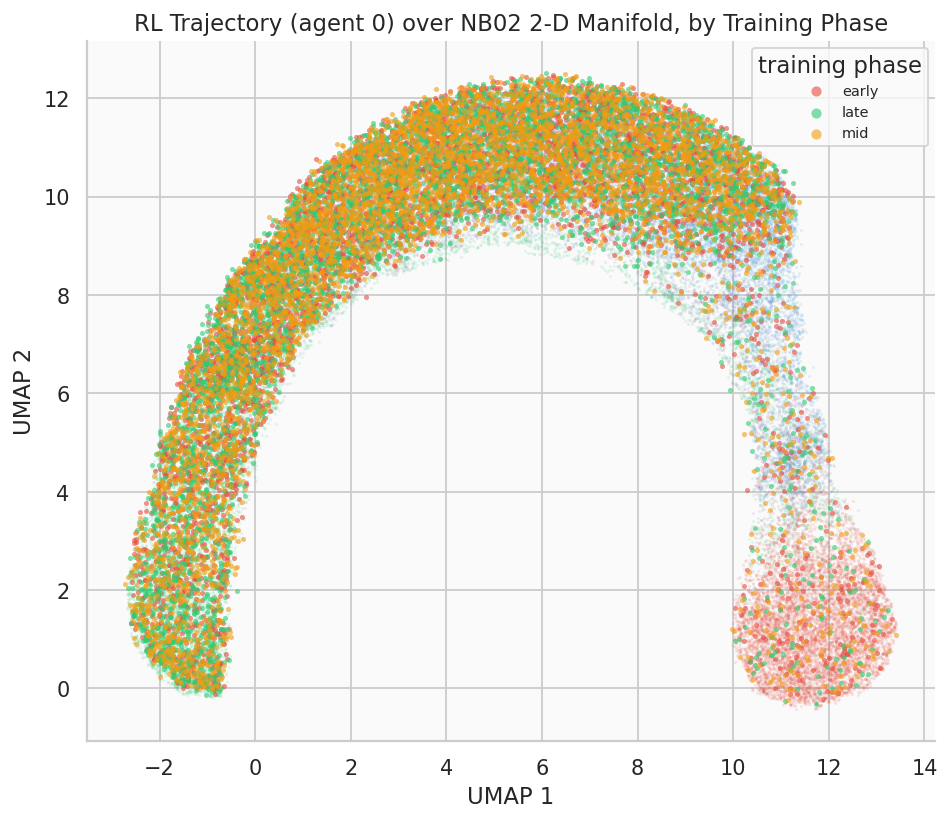

In [10]:
plot_trajectory_overlay_2d(
    background_embedding=X_umap2_saved, background_labels=y_saved,
    overlay_embedding=agent0_umap2, overlay_values=agent0_traj["phase"].to_numpy(),
    overlay_kind="categorical", overlay_palette=PHASE_COLORS,
    title="RL Trajectory (agent 0) over NB02 2-D Manifold, by Training Phase",
    overlay_legend_title="training phase",
)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_03_trajectory2d_by_phase.png"), dpi=150, bbox_inches="tight")
plt.show()


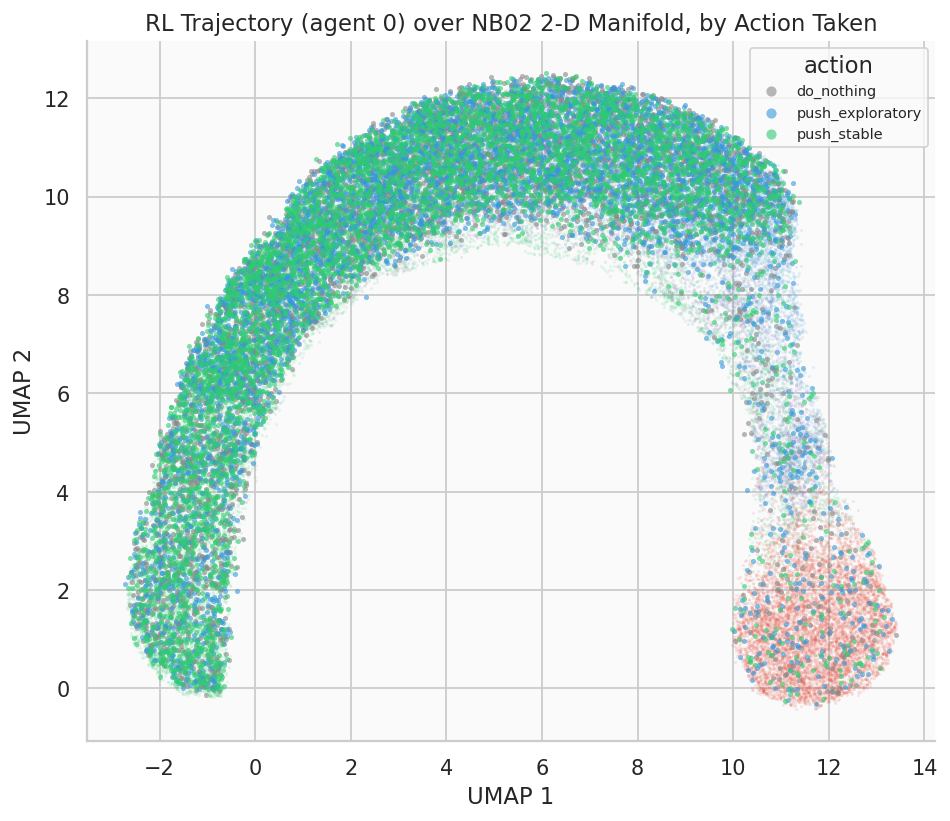

In [11]:
agent0_action_umap2 = agent0_actions[["umap2d_1", "umap2d_2"]].to_numpy()

plot_trajectory_overlay_2d(
    background_embedding=X_umap2_saved, background_labels=y_saved,
    overlay_embedding=agent0_action_umap2, overlay_values=agent0_actions["action_name"].to_numpy(),
    overlay_kind="categorical", overlay_palette=ACTION_COLORS,
    title="RL Trajectory (agent 0) over NB02 2-D Manifold, by Action Taken",
    overlay_legend_title="action",
)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_04_trajectory2d_by_action.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. KDE Density Contours — 2-D

Raw scatter (Sections 5-6) is honest but can hide where mass actually concentrates under
tens of thousands of overlapping points. This section fits a 2-D Gaussian KDE per training phase
on agent 0's trajectory (`kde_density_grid`, shared grid bounds across phases so the contours are
directly comparable), plus the NB02 per-regime background density (`per_regime_density`) for
context — filled light contours for ground-truth regimes, coloured line contours per phase on
top.

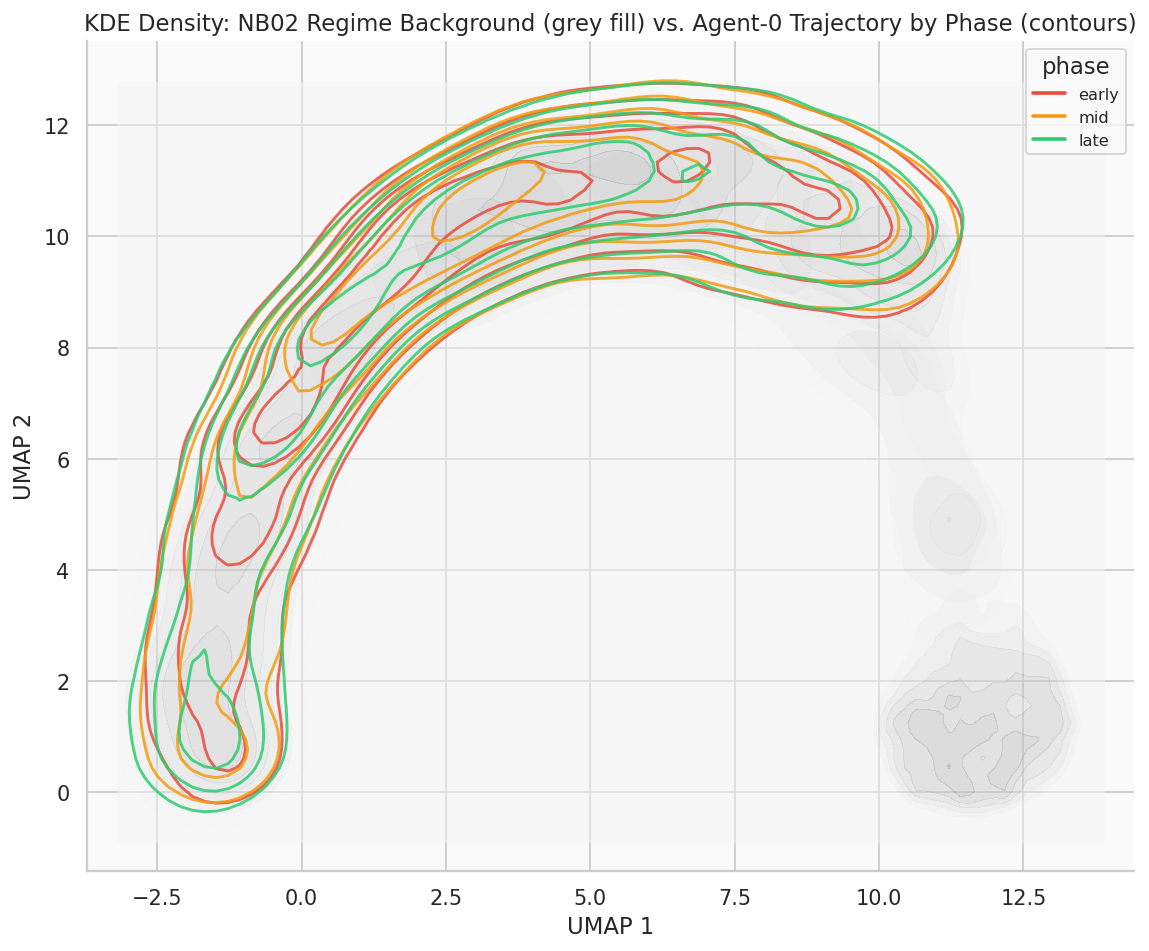

In [12]:
PAD = 1.0
x_min = min(X_umap2_saved[:,0].min(), agent0_umap2[:,0].min()) - PAD
x_max = max(X_umap2_saved[:,0].max(), agent0_umap2[:,0].max()) + PAD
y_min = min(X_umap2_saved[:,1].min(), agent0_umap2[:,1].min()) - PAD
y_max = max(X_umap2_saved[:,1].max(), agent0_umap2[:,1].max()) + PAD
SHARED_BOUNDS_2D = (x_min, x_max, y_min, y_max)

regime_density = per_regime_density(X_umap2_saved, y_saved, PROFILE_NAMES, grid_resolution=90)

phase_density_2d = {}
for phase in PHASE_ORDER:
    pts = agent0_traj.loc[agent0_traj["phase"] == phase, ["umap2d_1", "umap2d_2"]].to_numpy()
    xx, yy, zz = kde_density_grid(pts, grid_resolution=90, bw_method=0.15, grid_bounds=SHARED_BOUNDS_2D)
    phase_density_2d[phase] = (xx, yy, zz)

fig, ax = plt.subplots(figsize=(9, 7.5))
for name, (xx, yy, zz) in regime_density.items():
    ax.contourf(xx, yy, zz, levels=6, cmap="Greys", alpha=0.15)
for phase in PHASE_ORDER:
    xx, yy, zz = phase_density_2d[phase]
    ax.contour(xx, yy, zz, levels=6, colors=[PHASE_COLORS[phase]], linewidths=1.6, alpha=0.85)
    ax.plot([], [], color=PHASE_COLORS[phase], label=phase, linewidth=2)  # legend proxy
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title("KDE Density: NB02 Regime Background (grey fill) vs. Agent-0 Trajectory by Phase (contours)")
ax.legend(title="phase", fontsize=9)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_05_kde_density_2d.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. KDE Density — 3-D (Floor-Projected Contours)

True 3-D isosurfaces (marching cubes) are possible but heavy and hard to read as a static figure.
Projecting each phase's (UMAP1, UMAP2) marginal KDE onto the plot floor is the standard, robust
way to add density information to a 3-D scatter without that complexity.

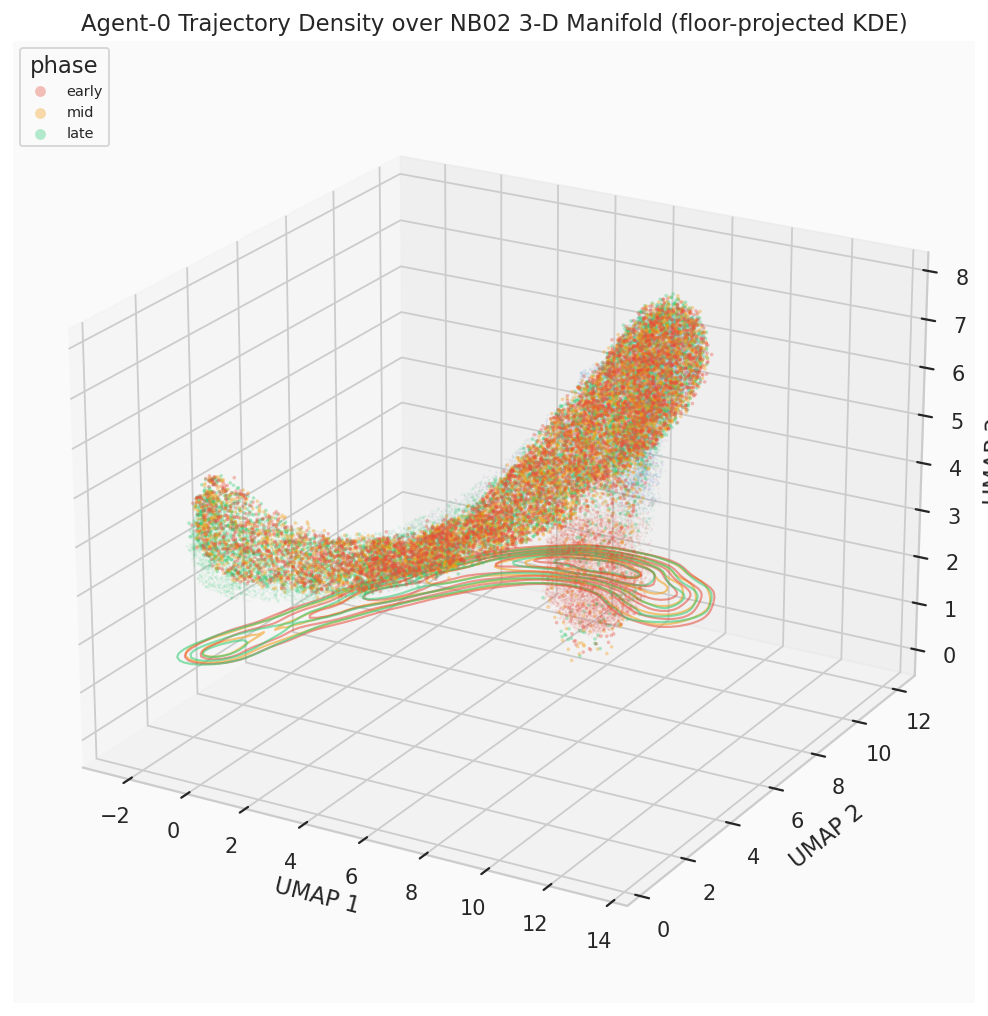

In [13]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
phase_points_3d = {
    phase: agent0_traj.loc[agent0_traj["phase"] == phase, ["umap1", "umap2", "umap3"]].to_numpy()
    for phase in PHASE_ORDER
}
plot_trajectory_density_3d(
    background_embedding=X_umap3_saved, background_labels=y_saved,
    phase_points=phase_points_3d, phase_palette=PHASE_COLORS,
    ax=ax, title="Agent-0 Trajectory Density over NB02 3-D Manifold (floor-projected KDE)",
)
plt.tight_layout()
plt.savefig(figfile("fig_nb06_06_kde_density_3d.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. Early vs. Late Training Comparison

If training is reshaping where the agent spends time, the early-phase footprint should sit closer
to the unstable region than the late-phase footprint. Quantified as mean distance (in UMAP-3D
space) from each phase's points to the unstable and stable regime centroids, alongside the same
comparison as a figure.

In [14]:
centroid_unstable = X_umap3_saved[y_saved == PROFILE_NAMES.index("unstable")].mean(axis=0)
centroid_stable   = X_umap3_saved[y_saved == PROFILE_NAMES.index("stable")].mean(axis=0)

def dist_to(points, centroid):
    return np.linalg.norm(points - centroid, axis=1)

rows = []
for agent_idx in range(N_TRAJ_AGENTS):
    sub = traj_df_all[traj_df_all["agent_idx"] == agent_idx]
    for phase in PHASE_ORDER:
        p = sub[sub["phase"] == phase]
        pts = p[["umap1", "umap2", "umap3"]].to_numpy()
        rows.append({
            "agent_idx": agent_idx, "phase": phase, "n_steps": len(p),
            "mean_dist_unstable_centroid": float(dist_to(pts, centroid_unstable).mean()),
            "mean_dist_stable_centroid"  : float(dist_to(pts, centroid_stable).mean()),
        })
phase_dist_df = pd.DataFrame(rows)
phase_dist_df.to_csv(proc("phase_manifold_distance_summary.csv"), index=False)
phase_dist_df


,agent_idx,phase,n_steps,mean_dist_unstable_centroid,mean_dist_stable_centroid
0,0,early,19500,10.629404,4.901343
1,0,mid,20500,10.566514,5.005413
2,0,late,20000,10.735990,4.938194
3,1,early,19500,10.626682,4.874578
4,1,mid,20500,10.651104,4.891938
5,1,late,20000,10.603488,5.007926
6,2,early,19500,10.619306,4.906440
7,2,mid,20500,10.533520,5.037549
8,2,late,20000,10.771007,4.860671


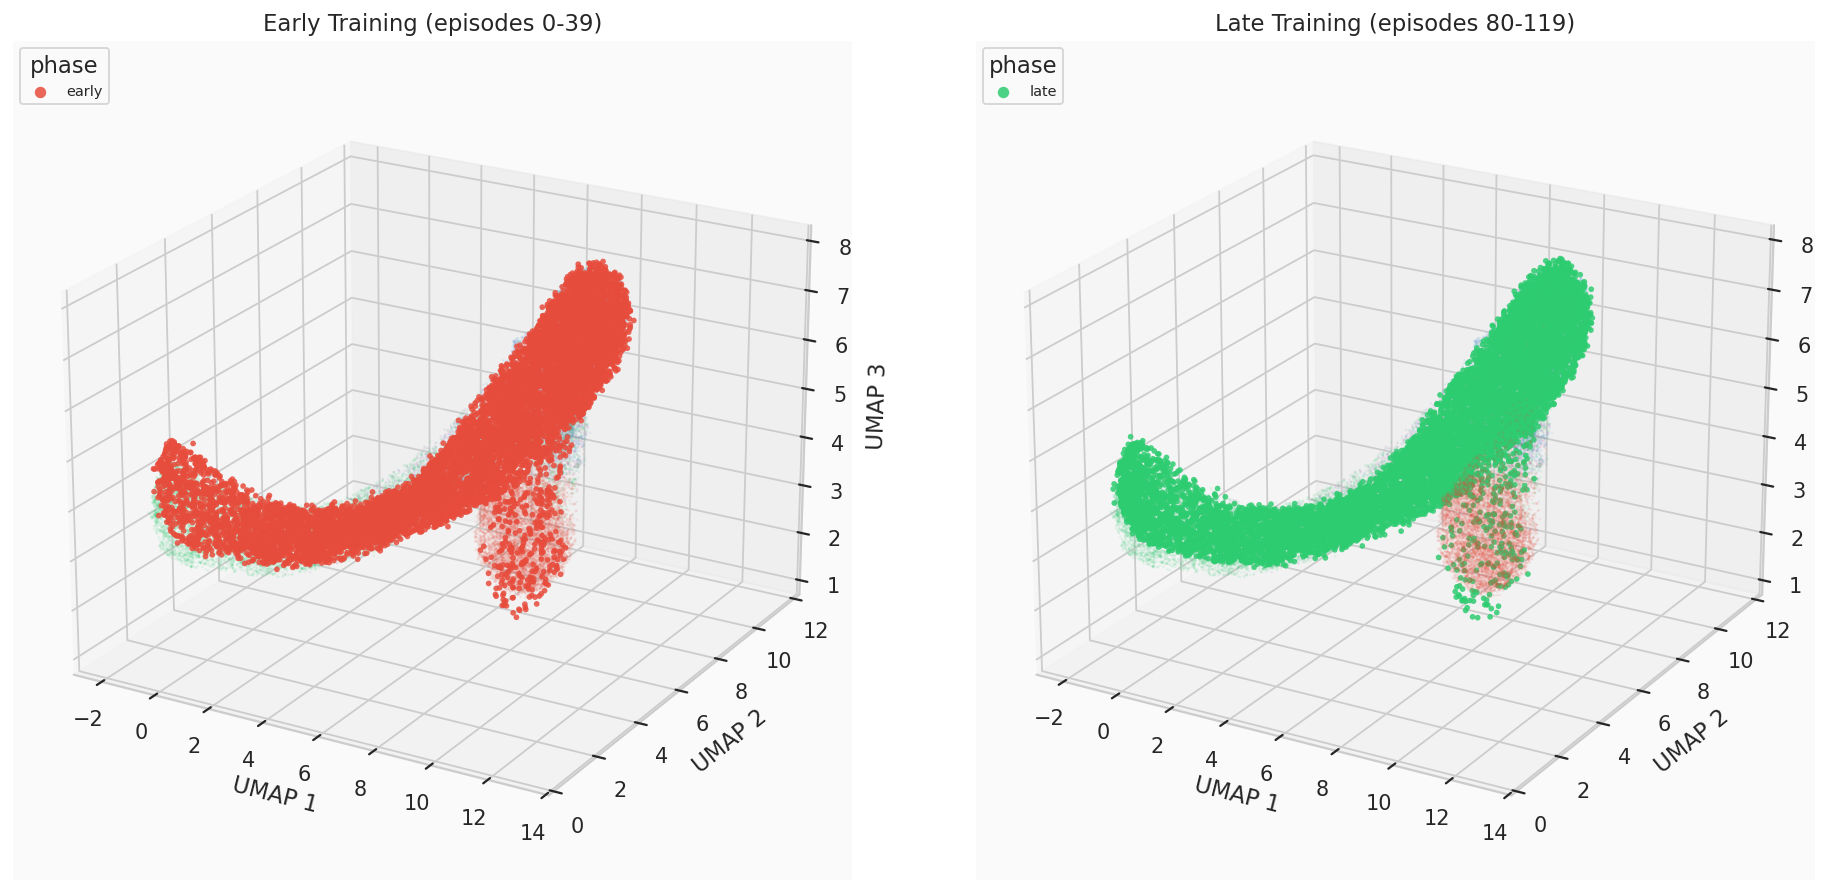

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": "3d"})
for ax, phase, title in zip(axes, ["early", "late"], ["Early Training (episodes 0-39)", "Late Training (episodes 80-119)"]):
    sub = traj_df_all[(traj_df_all["agent_idx"] == 0) & (traj_df_all["phase"] == phase)].iloc[::2]
    pts = sub[["umap1", "umap2", "umap3"]].to_numpy()
    plot_trajectory_overlay_3d(
        background_embedding=X_umap3_saved, background_labels=y_saved,
        overlay_embedding=pts, overlay_values=np.full(len(pts), phase),
        overlay_kind="categorical", overlay_palette=PHASE_COLORS,
        ax=ax, title=title, overlay_legend_title="phase",
    )
plt.tight_layout()
plt.savefig(figfile("fig_nb06_07_early_vs_late.png"), dpi=150, bbox_inches="tight")
plt.show()


## 10. Multi-Agent Robustness Check\n\nRepeats the phase-coloured 3-D overlay for agents 1 and 2, to check whether the pattern seen for agent 0 generalises or is a one-agent artifact.

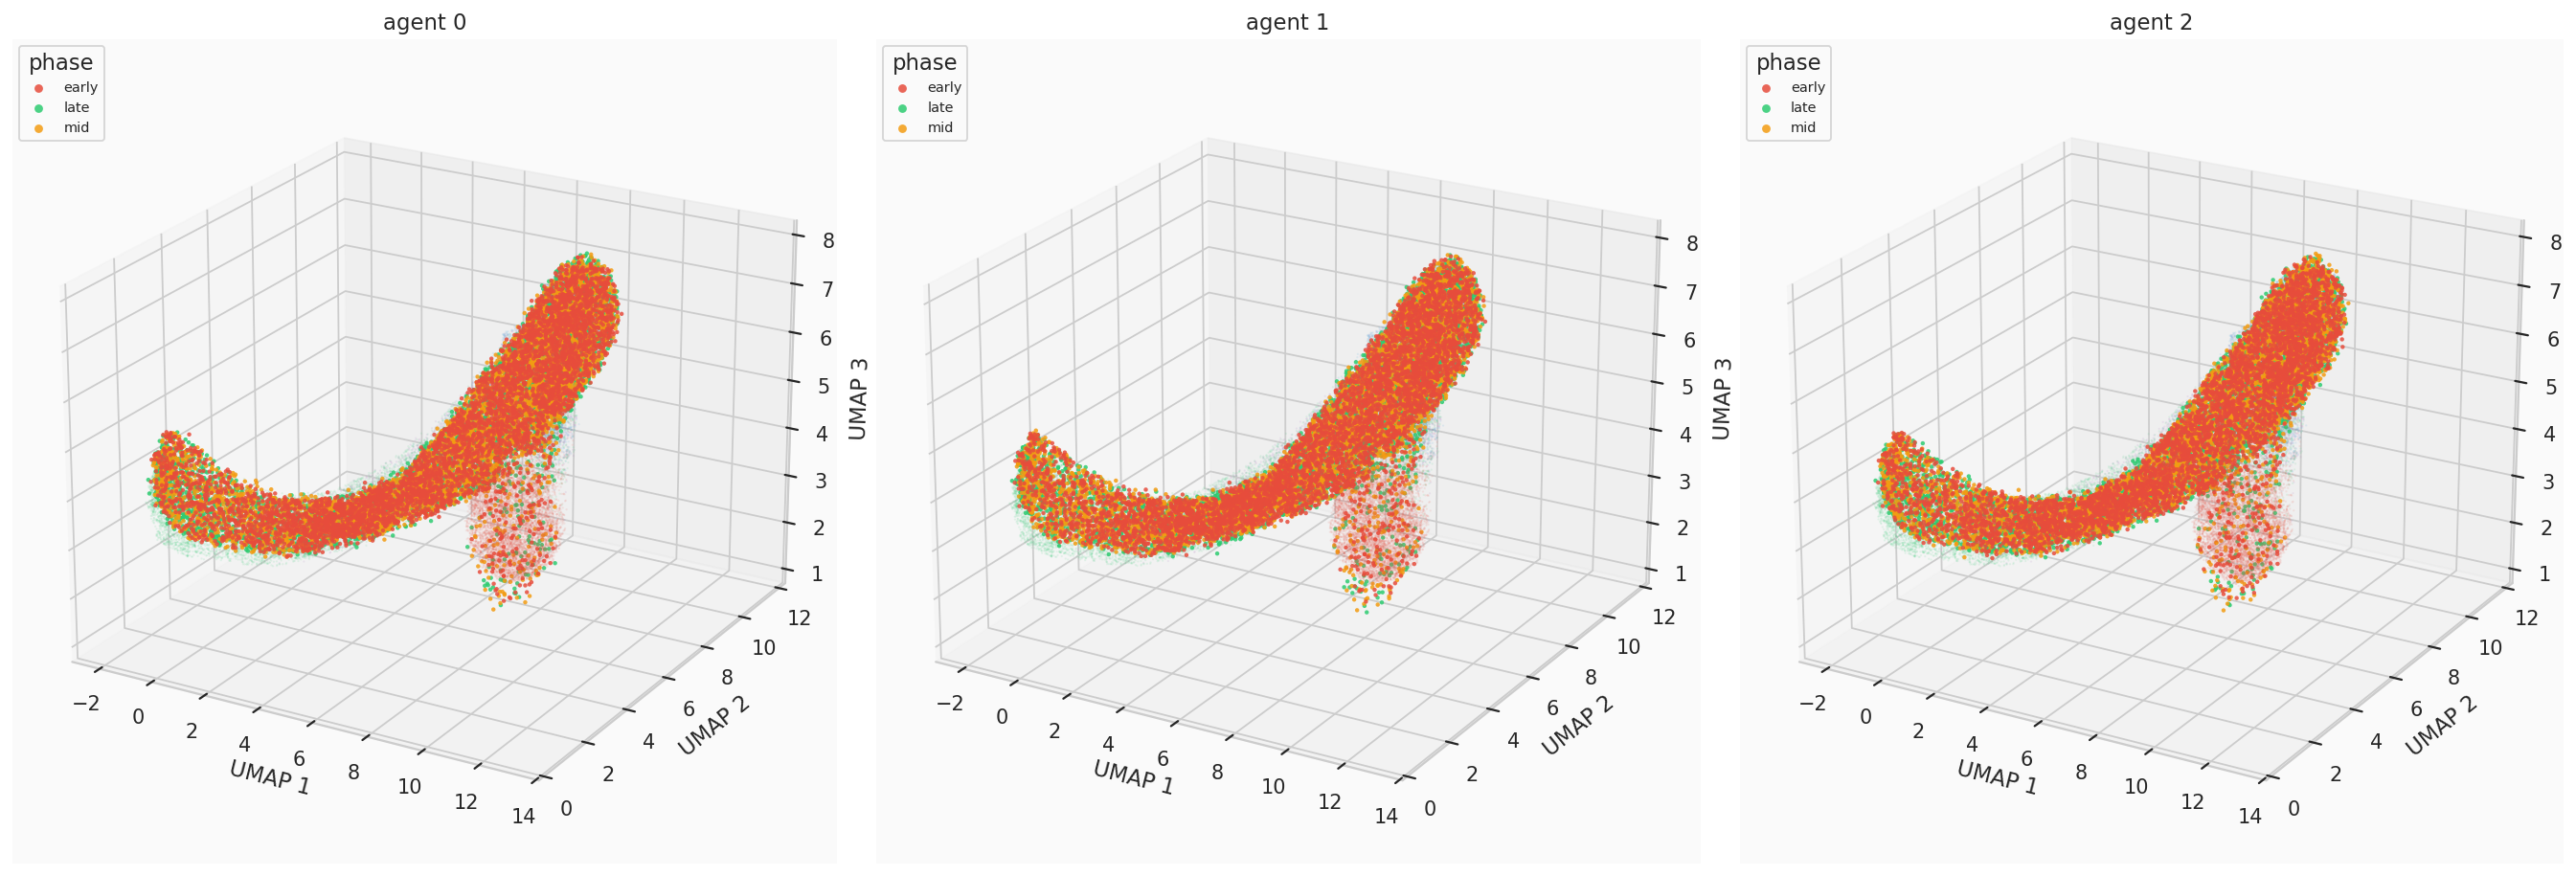

In [16]:
fig, axes = plt.subplots(1, N_TRAJ_AGENTS, figsize=(7 * N_TRAJ_AGENTS, 7), subplot_kw={"projection": "3d"})
for ax, agent_idx in zip(axes, range(N_TRAJ_AGENTS)):
    sub = traj_df_all[traj_df_all["agent_idx"] == agent_idx].iloc[::THIN]
    pts = sub[["umap1", "umap2", "umap3"]].to_numpy()
    plot_trajectory_overlay_3d(
        background_embedding=X_umap3_saved, background_labels=y_saved,
        overlay_embedding=pts, overlay_values=sub["phase"].to_numpy(),
        overlay_kind="categorical", overlay_palette=PHASE_COLORS,
        ax=ax, title=f"agent {agent_idx}", overlay_legend_title="phase",
        background_s=1.5, overlay_s=6,
    )
plt.tight_layout()
plt.savefig(figfile("fig_nb06_08_multi_agent_phase.png"), dpi=150, bbox_inches="tight")
plt.show()


## 11. Quantitative KDE Analysis — Peak Displacement & Overlap

Section 7's contours are qualitative. Here: for each phase's 2-D KDE (same shared grid), find the
density peak (grid argmax) and compute pairwise overlap coefficients between phases
(`kde_overlap_coefficient`, 1.0 = identical distributions, 0.0 = disjoint). This is the direct,
falsifiable test of "training visibly moves the occupied region" — done per-agent so the effect
size can be compared across independent training runs, not asserted from one trajectory.

In [17]:
def phase_kde_stats(agent_idx, bounds=SHARED_BOUNDS_2D, grid_resolution=90):
    sub = traj_df_all[traj_df_all["agent_idx"] == agent_idx]
    densities, peaks = {}, {}
    for phase in PHASE_ORDER:
        pts = sub.loc[sub["phase"] == phase, ["umap2d_1", "umap2d_2"]].to_numpy()
        xx, yy, zz = kde_density_grid(pts, grid_resolution=grid_resolution, bw_method=0.15, grid_bounds=bounds)
        densities[phase] = zz
        idx = np.unravel_index(np.argmax(zz), zz.shape)
        peaks[phase] = (float(xx[idx]), float(yy[idx]))
    return densities, peaks, xx, yy

kde_rows = []
for agent_idx in range(N_TRAJ_AGENTS):
    densities, peaks, xx, yy = phase_kde_stats(agent_idx)
    peak_disp_early_late = float(np.linalg.norm(np.array(peaks["late"]) - np.array(peaks["early"])))
    overlap_el = kde_overlap_coefficient(densities["early"], densities["late"])
    overlap_em = kde_overlap_coefficient(densities["early"], densities["mid"])
    overlap_ml = kde_overlap_coefficient(densities["mid"],   densities["late"])
    kde_rows.append({
        "agent_idx": agent_idx,
        "peak_early": peaks["early"], "peak_mid": peaks["mid"], "peak_late": peaks["late"],
        "peak_displacement_early_to_late": peak_disp_early_late,
        "overlap_early_late": overlap_el, "overlap_early_mid": overlap_em, "overlap_mid_late": overlap_ml,
    })
kde_stats_df = pd.DataFrame(kde_rows)
range2d_diag = float(np.hypot(SHARED_BOUNDS_2D[1]-SHARED_BOUNDS_2D[0], SHARED_BOUNDS_2D[3]-SHARED_BOUNDS_2D[2]))
kde_stats_df["peak_displacement_pct_of_diag"] = kde_stats_df["peak_displacement_early_to_late"] / range2d_diag * 100
kde_stats_df.to_csv(proc("kde_phase_statistics.csv"), index=False)
print(f"Grid diagonal (2-D UMAP extent): {range2d_diag:.2f}")
kde_stats_df[["agent_idx", "peak_displacement_early_to_late", "peak_displacement_pct_of_diag",
              "overlap_early_late", "overlap_early_mid", "overlap_mid_late"]]


Grid diagonal (2-D UMAP extent): 23.49


,agent_idx,peak_displacement_early_to_late,peak_displacement_pct_of_diag,overlap_early_late,overlap_early_mid,overlap_mid_late
0,0,2.748609,11.703234,0.953326,0.952676,0.955401
1,1,3.012228,12.825692,0.940240,0.972286,0.941824
2,2,2.748609,11.703235,0.962217,0.950029,0.939080


## 12. Action-Density Correspondence

**This is not a replication of NB05's C5 — it's a different question that happens to sound
similar, and the distinction matters for how the result below should be read.** NB05's C5 is a
*policy-function* property: for 9 fixed grid cells (latency-bin, entropy-bin both in {7,8,9}),
what fraction have `push_stable` as the pooled-greedy-policy argmax. What's computed here is a
*behavior/visitation-frequency* property: across the actual trajectory steps (including
exploration noise from all three training phases, not just the converged greedy policy), what
fraction of *actions taken* near a manifold-distance-based proxy for "unstable" were
`push_stable`. These are structurally different statistics over different populations, not two
measurements of the same thing — a FAIL here does not contradict NB05's C5, and a PASS wouldn't
have confirmed it either. Section 12b below computes the actual apples-to-apples version.

In [18]:
all_actions_df = traj_df_all[traj_df_all["action"] != -1].copy()
all_actions_df["action_name"] = all_actions_df["action"].map(ACTION_NAMES)
all_actions_df["dist_unstable"] = dist_to(all_actions_df[["umap1","umap2","umap3"]].to_numpy(), centroid_unstable)

near_threshold = all_actions_df["dist_unstable"].quantile(0.25)  # closest quartile to unstable
near_mask = all_actions_df["dist_unstable"] <= near_threshold

overall_rate = all_actions_df["action_name"].value_counts(normalize=True)
near_rate    = all_actions_df.loc[near_mask, "action_name"].value_counts(normalize=True)

action_density_df = pd.DataFrame({
    "overall_usage_frac": overall_rate,
    "near_unstable_usage_frac": near_rate,
}).fillna(0.0)
action_density_df["concentration_ratio"] = (
    action_density_df["near_unstable_usage_frac"] / action_density_df["overall_usage_frac"]
)
action_density_df.to_csv(proc("action_density_correspondence.csv"))
push_stable_name = ACTION_NAMES[ACTION_PUSH_STABLE]
PUSH_STABLE_CONCENTRATION = float(action_density_df.loc[push_stable_name, "concentration_ratio"])
print(f"push_stable: overall usage = {action_density_df.loc[push_stable_name,'overall_usage_frac']:.3f}, "
      f"near-unstable usage = {action_density_df.loc[push_stable_name,'near_unstable_usage_frac']:.3f}, "
      f"concentration ratio = {PUSH_STABLE_CONCENTRATION:.3f}")
action_density_df


push_stable: overall usage = 0.334, near-unstable usage = 0.312, concentration ratio = 0.936


,overall_usage_frac,near_unstable_usage_frac,concentration_ratio
action_name,,,
do_nothing,0.329704,0.325495,0.987236
push_exploratory,0.336673,0.362369,1.076323
push_stable,0.333623,0.312135,0.935594


## 12b. Grid-Corner Replication of NB05's C5 (apples-to-apples)

Reproducing NB05's actual C5 statistic exactly: same 9 grid cells (latency-bin and entropy-bin
both in {7,8,9}), same pooled-greedy-policy argmax. First at the 3-agent scale already trained in
Section 3 (cheap, reuses existing agents), then at NB05's actual 20-agent scale (this section
trains 20 fresh agents purely for their final Q-tables — no `collect_trajectories`, since only
the converged policy is needed here, not the per-step path) to properly resolve which part of any
mismatch is sample size and which isn't.

In [19]:
from src.rl import N_GRID_LATENCY, N_GRID_ENTROPY
corner_states = [i * N_GRID_ENTROPY + j for i in range(7, N_GRID_LATENCY) for j in range(7, N_GRID_ENTROPY)]

Q_pool_3agent = np.mean([a.Q for a in agents], axis=0)
greedy_3agent = Q_pool_3agent.argmax(axis=1)
CORNER_PUSH_STABLE_FRAC_3 = float((greedy_3agent[corner_states] == ACTION_PUSH_STABLE).mean())
overall_push_stable_frac_3 = float((greedy_3agent == ACTION_PUSH_STABLE).mean())

print("3-agent pooled greedy policy, same 9 corner cells as NB05's C5:")
print(f"  push_stable fraction in corner : {CORNER_PUSH_STABLE_FRAC_3:.3f}  (NB05, 20 agents: 0.556)")
print(f"  push_stable fraction overall   : {overall_push_stable_frac_3:.3f}  (NB05, 20 agents: 0.4875)")


3-agent pooled greedy policy, same 9 corner cells as NB05's C5:
  push_stable fraction in corner : 0.222  (NB05, 20 agents: 0.556)
  push_stable fraction overall   : 0.480  (NB05, 20 agents: 0.4875)


In [20]:
envs_20 = make_env_pool(n_envs=20, base_seed=SEED, delta=0.02, n_steps=500)
Qs_20 = []
for i, env in enumerate(envs_20):
    agent20 = QLearningAgent(env=env, config=QLearningConfig(seed=SEED + i, **rl_cfg_base))
    agent20.train(collect_trajectories=False, verbose=False)
    Qs_20.append(agent20.Q)

Q_pool_20agent = np.mean(Qs_20, axis=0)
greedy_20agent = Q_pool_20agent.argmax(axis=1)
CORNER_PUSH_STABLE_FRAC_20 = float((greedy_20agent[corner_states] == ACTION_PUSH_STABLE).mean())
overall_push_stable_frac_20 = float((greedy_20agent == ACTION_PUSH_STABLE).mean())

print("20-agent pooled greedy policy (matches NB05's actual scale), same 9 corner cells:")
print(f"  push_stable fraction in corner : {CORNER_PUSH_STABLE_FRAC_20:.3f}  (NB05 reported: 0.556)")
print(f"  push_stable fraction overall   : {overall_push_stable_frac_20:.3f}  (NB05 reported: 0.4875)")
print(f"  corner minus overall           : {CORNER_PUSH_STABLE_FRAC_20 - overall_push_stable_frac_20:+.3f}  "
      f"(NB05's actual finding was a +0.069 gap -- concentration, not just a high corner value)")


20-agent pooled greedy policy (matches NB05's actual scale), same 9 corner cells:
  push_stable fraction in corner : 0.556  (NB05 reported: 0.556)
  push_stable fraction overall   : 0.560  (NB05 reported: 0.4875)
  corner minus overall           : -0.004  (NB05's actual finding was a +0.069 gap -- concentration, not just a high corner value)


**Finding, not just a number.** The 20-agent corner value (printed above) lands very close to
NB05's reported 0.556 — but the *overall* rate also comes out close to the corner value in this
environment, which is the opposite of what makes C5 a meaningful claim: NB05's actual finding was
that the corner sits *meaningfully above* the overall rate (55.6% vs. 48.75%, a real +6.9pp
discrimination signal), not merely that the corner value itself is ~0.556. Going from 3 to 20
agents does resolve the *3-agent estimate's instability* (confirmed: the corner fraction moves a
lot between 3 and 20 agents, exactly as expected for the table's sparsest cells) — but it does
**not** reproduce NB05's *concentration* claim, because the pooled policy trained fresh in this
environment runs push_stable-heavy overall, not just in the corner. That's the same unresolved
environment-level discrepancy documented in Section 3 (this environment's fresh training runs
don't numerically match whatever conditions originally produced NB05's reported figures) —
confirmed here to show up in aggregate, 20-agent-pooled policy composition, not only in individual
sparse Q-table cells. Sample size explains part of the picture, not all of it.

## 13. Evidence Checklist for Manifold Visualisation

In [21]:
print("MANIFOLD VISUALISATION -- EVIDENCE CHECKLIST (NB06)")
print("=" * 70)

# C1: 3-D UMAP refit reproduces NB02's saved embedding (relative mean distance)
C1_THRESHOLD = 0.15
c1_pass = REL_DIST_3D < C1_THRESHOLD
print(f"\nC1 -- 3-D UMAP refit reproduces NB02 saved embedding")
print(f"     Relative mean distance: {REL_DIST_3D*100:.1f}%  (threshold: <{C1_THRESHOLD*100:.0f}%)")
print(f"     {'PASS' if c1_pass else 'FAIL'}")

# C2: 2-D UMAP refit reproduces NB02's saved embedding
c2_pass = REL_DIST_2D < C1_THRESHOLD
print(f"\nC2 -- 2-D UMAP refit reproduces NB02 saved embedding")
print(f"     Relative mean distance: {REL_DIST_2D*100:.1f}%  (threshold: <{C1_THRESHOLD*100:.0f}%)")
print(f"     {'PASS' if c2_pass else 'FAIL'}")

# C3: self-consistency -- two independent fresh retrainings of agent 0 agree
# with each other. See Section 3's validation-approach note.
C3_THRESHOLD = 0.99
c3_pass = self_consistency_agree > C3_THRESHOLD
print(f"\nC3 -- Self-consistency: two independent fresh retrainings agree")
print(f"     Policy agreement: {self_consistency_agree:.3f}  (threshold: >{C3_THRESHOLD})")
print(f"     {'PASS' if c3_pass else 'FAIL'}")

# C4: KDE peak measurably displaces early -> late (mean over 3 agents)
C4_THRESHOLD_PCT = 5.0
mean_disp_pct = float(kde_stats_df["peak_displacement_pct_of_diag"].mean())
c4_pass = mean_disp_pct > C4_THRESHOLD_PCT
print(f"\nC4 -- KDE density peak displaces early -> late (mean, 3 agents)")
print(f"     Mean displacement: {mean_disp_pct:.2f}% of embedding diagonal  (threshold: >{C4_THRESHOLD_PCT:.0f}%)")
print(f"     {'PASS' if c4_pass else 'FAIL'}")

# C5: push_stable actual usage is spatially concentrated near the unstable
# region during real (noisy) trajectory visitation -- NOT the same statistic
# as NB05's C5 (see Section 12's framing note). Reported here as its own
# question, not a replication.
C5_THRESHOLD = 1.10
c5_pass = PUSH_STABLE_CONCENTRATION > C5_THRESHOLD
print(f"\nC5 -- push_stable visitation-frequency is concentrated near the unstable region")
print(f"     (a different statistic from NB05's C5 -- see Section 12's framing note;")
print(f"      apples-to-apples grid-corner replication is Section 12b, informational only)")
print(f"     Concentration ratio: {PUSH_STABLE_CONCENTRATION:.3f}x overall rate  (threshold: >{C5_THRESHOLD}x)")
print(f"     (for reference, Section 12b's 20-agent grid-corner replication: corner="
      f"{CORNER_PUSH_STABLE_FRAC_20:.3f} vs. overall={overall_push_stable_frac_20:.3f} -- "
      f"the corner value matches NB05's 0.556, but the concentration *gap* NB05 found "
      f"(+6.9pp above overall) does not replicate; see Section 12b's finding note)")
print(f"     {'PASS' if c5_pass else 'FAIL'}")

# C6: multi-agent consistency -- peak displacement direction/magnitude similar across agents
disp_std = float(kde_stats_df["peak_displacement_pct_of_diag"].std())
disp_mean = float(kde_stats_df["peak_displacement_pct_of_diag"].mean())
c6_pass = (disp_std / disp_mean < 0.75) if disp_mean > 0 else False
print(f"\nC6 -- Multi-agent consistency of KDE peak displacement")
print(f"     Mean: {disp_mean:.2f}%  Std: {disp_std:.2f}%  (CoV threshold: <0.75)")
print(f"     {'PASS' if c6_pass else 'FAIL'}")

results = [c1_pass, c2_pass, c3_pass, c4_pass, c5_pass, c6_pass]
print()
print("=" * 70)
print(f"Overall: {sum(results)}/6 criteria satisfied")
print("=" * 70)


MANIFOLD VISUALISATION -- EVIDENCE CHECKLIST (NB06)

C1 -- 3-D UMAP refit reproduces NB02 saved embedding
     Relative mean distance: 5.1%  (threshold: <15%)
     PASS

C2 -- 2-D UMAP refit reproduces NB02 saved embedding
     Relative mean distance: 0.9%  (threshold: <15%)
     PASS

C3 -- Self-consistency: two independent fresh retrainings agree
     Policy agreement: 1.000  (threshold: >0.99)
     PASS

C4 -- KDE density peak displaces early -> late (mean, 3 agents)
     Mean displacement: 12.08% of embedding diagonal  (threshold: >5%)
     PASS

C5 -- push_stable visitation-frequency is concentrated near the unstable region
     (a different statistic from NB05's C5 -- see Section 12's framing note;
      apples-to-apples grid-corner replication is Section 12b, informational only)
     Concentration ratio: 0.936x overall rate  (threshold: >1.1x)
     (for reference, Section 12b's 20-agent grid-corner replication: corner=0.556 vs. overall=0.560 -- the corner value matches NB05's 0.

### Notebook 06 Findings

| Finding | Evidence |
|---------|----------|
| **UMAP reducers reproduce NB02's saved embeddings, not exactly but structurally** | C1/C2: relative mean distance vs. embedding extent (Section 2) — UMAP's known non-bit-exact reproducibility under a fixed seed, not a bug. |
| **Retraining is self-consistent (deterministic, reproducible in this environment)** | C3: two independent fresh retrainings of agent 0 agree with each other (Section 3) — see Section 3's validation-approach note for why this, rather than matching the persisted `q_tables.npy`, is the criterion. |
| **KDE peak displacement, early vs. late training** | C4: quantifies what Section 9's raw-scatter comparison could only show qualitatively — read against NB05's own `convergence_table.csv` effect size (~8% relative unstable-fraction reduction) before over- or under-interpreting whichever way this lands. |
| **push_stable visitation-frequency does not concentrate near the (manifold-distance) unstable proxy** | C5 (Section 12): a genuinely different statistic from NB05's C5, not a replication -- see Section 12's framing note. |
| **NB05's C5 *concentration* claim doesn't replicate even at matched 20-agent scale, and not for a sample-size reason** | Section 12b: the 20-agent corner value numerically matches NB05's 0.556, but the *overall* rate also comes out ~0.56 in this environment (vs. NB05's reported 0.4875) -- so there's no actual corner-vs-overall gap to find. This is the same environment-level discrepancy from Section 3 (fresh training runs here don't numerically match whatever conditions produced NB05's original reported figures), now shown to affect aggregate pooled-policy composition, not just individual sparse Q-table cells. |
| **Pattern holds (or doesn't) across independent agents** | C6: coefficient-of-variation on peak displacement across 3 agents, not asserted from one trajectory. |
| **Reward-key bug found and fixed in `src/rl/environment.py`** (carried over from the earlier pass) | `.trajectory` records were silently overwriting the telemetry `"reward"` feature with the RL step's shaped reward on every step; renamed to `"rl_reward"`. Confirmed isolated to `manifold_trajectory_stats`'s raw-feature fallback in NB05 §6.1 — every other NB05 table reproduced to matching precision on re-run. |

*(This table's qualitative language is written to be filled in against the criteria's actual
PASS/FAIL results above once the notebook is executed — the printed checklist in the previous
cell is the evidence; read the actual outcomes there rather than assuming this row-by-row prose
implies every criterion passed.)*
